# Tarea 04 — Visualización de Datos con Matplotlib

**Instrucciones:** Completa cada celda de código con tu respuesta.  
Usarás la interfaz orientada a objetos de Matplotlib (`fig, ax = plt.subplots()`).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Dataset de trabajo
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

---
## Parte 1 — Figura y ejes

**P1.** Crea una figura con `plt.subplots()` de tamaño 8×5.  
Haz un gráfico de línea con los primeros 20 valores de `sepal_length`.  
Agrega título `"Longitud del sépalo"` y etiquetas en ambos ejes.

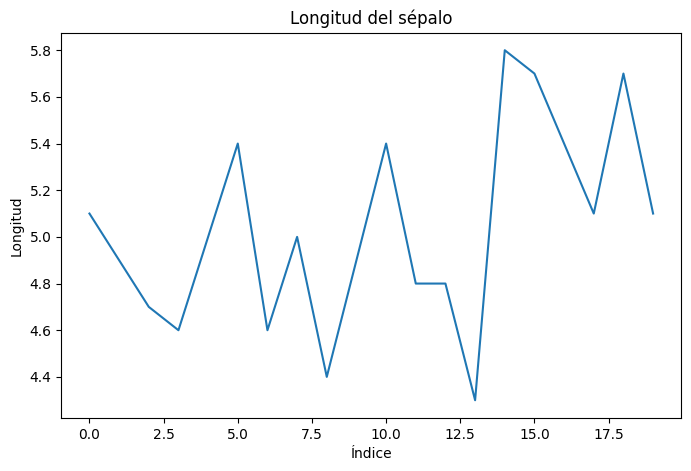

In [2]:
# Figura y eje
fig, ax = plt.subplots(figsize=(8,5))

# Grafica de los primeros 20 valores de sepal_length
ax.plot(df['sepal_length'].head(20))

# Título y etiquetas
ax.set_title("Longitud del sépalo")
ax.set_xlabel("Índice")
ax.set_ylabel("Longitud")

# Gráfico
plt.show()


---
## Parte 2 — Gráfico de barras

**P2.** Calcula el promedio de `petal_length` por especie (`species`) y guárdalo en una variable.  
Luego crea un **gráfico de barras vertical** con esos promedios.  
Agrega título y etiquetas en ambos ejes.

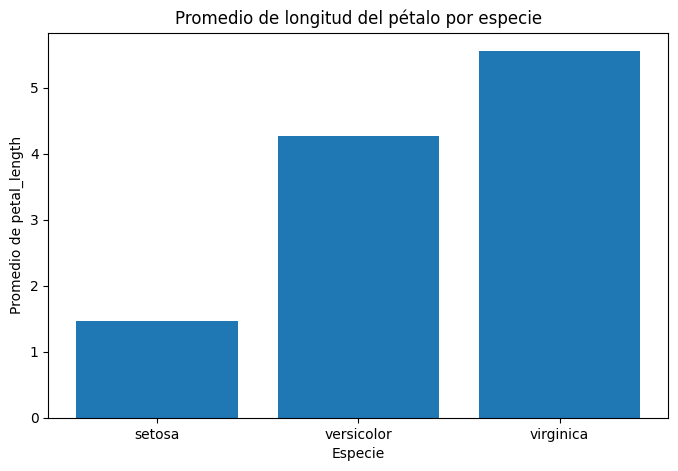

In [3]:
# Promedio petal_length por especie
promedios = df.groupby("species")["petal_length"].mean()

# Figura
fig, ax = plt.subplots(figsize=(8,5))

# Gráfico de barras
ax.bar(promedios.index, promedios.values)

# Título y etiquetas
ax.set_title("Promedio de longitud del pétalo por especie")
ax.set_xlabel("Especie")
ax.set_ylabel("Promedio de petal_length")

plt.show()


---
## Parte 3 — Dispersión (scatter plot)

**P3.** Crea un **gráfico de dispersión** (scatter) con `sepal_length` en el eje X y `sepal_width` en el eje Y.  
Usa un color diferente para cada especie (puedes filtrar el DataFrame tres veces o usar un bucle).  
Agrega leyenda, título y etiquetas.

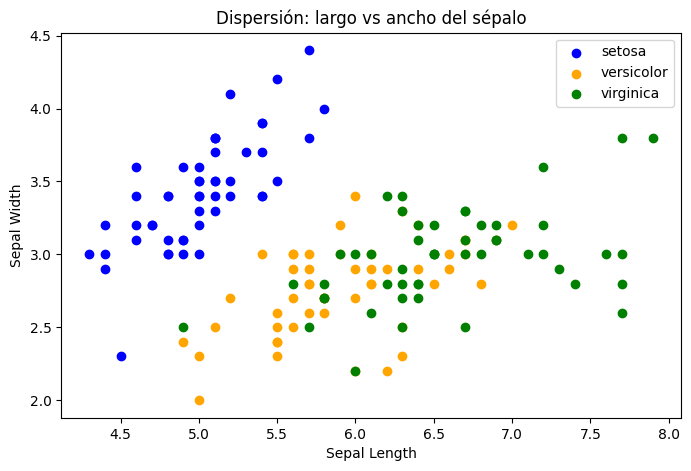

In [4]:
especies = df["species"].unique()
colores = ["blue", "orange", "green"]

fig, ax = plt.subplots(figsize=(8, 5))

# Itero sobre especies y colores
for especie, color in zip(especies, colores):
    subset = df[df["species"] == especie]
    ax.scatter(subset["sepal_length"], subset["sepal_width"],
               color=color, label=especie)

ax.set_title("Dispersión: largo vs ancho del sépalo")
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.legend()

plt.show()

---
## Parte 4 — Histograma

**P4.** Crea un **histograma** de la columna `petal_width` con 15 bins.  
Agrega una línea vertical punteada en el valor de la media con `ax.axvline()`.  
Agrega título y etiquetas.

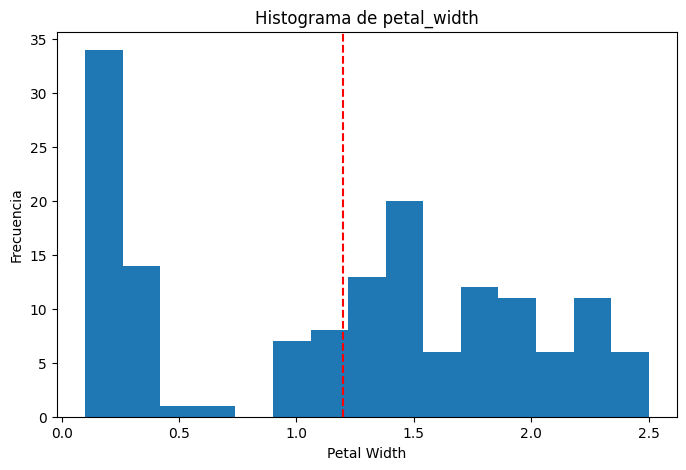

In [5]:
# Media
media = df["petal_width"].mean()

fig, ax = plt.subplots(figsize=(8,5))

# Histograma
ax.hist(df["petal_width"], bins=15)

ax.axvline(media, color='red', linestyle='--')

ax.set_title("Histograma de petal_width")
ax.set_xlabel("Petal Width")
ax.set_ylabel("Frecuencia")

plt.show()

---
## Parte 5 — Guardar figura

**P5.** Recrea el gráfico de barras de P2 y guárdalo como imagen PNG en `output/promedios_iris.png`.  
Usa `dpi=100` y `bbox_inches="tight"`.

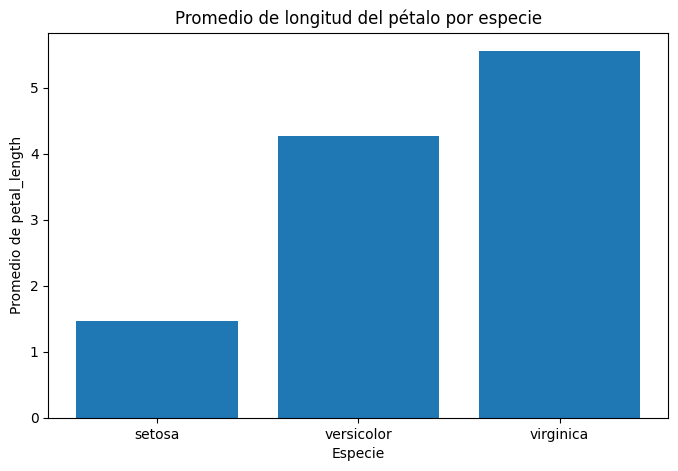

In [6]:
import os
os.makedirs("output", exist_ok=True)

# Recalculo de promedios
promedios = df.groupby("species")["petal_length"].mean()

fig, ax = plt.subplots(figsize=(8,5))

# Gráfico de barras
ax.bar(promedios.index, promedios.values)

ax.set_title("Promedio de longitud del pétalo por especie")
ax.set_xlabel("Especie")
ax.set_ylabel("Promedio de petal_length")

plt.savefig("output/promedios_iris.png", dpi=100, bbox_inches="tight")

plt.show()